In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Thiết lập đường dẫn Google Drive
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")
BASE = Path("/content/drive/MyDrive/Project")

print(f"✓ Base: {BASE}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Base: /content/drive/MyDrive/Project


In [3]:
# Tạo cấu trúc thư mục trên Drive
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Project")

dirs = [
    BASE / "src",
    BASE / "data" / "raw",
    BASE / "results",
    BASE / "notebooks",
]
for d in dirs:
    d.mkdir(parents=True, exist_ok=True)
print("✓ Tạo thư mục xong")

✓ Tạo thư mục xong


In [4]:
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Project")

required_files = [
    BASE / "src" / "runner.py",
    BASE / "notebooks" / "02_baseline.ipynb",
    BASE / "notebooks" / "03_simulate.ipynb",
    BASE / "data" / "raw" / "mbpp_subset.json",
]

all_found = True
for path in required_files:
    if path.exists():
        print(f"✅ File '{path.name}' found.")
    else:
        print(f"❌ Error: File '{path.name}' not found at '{path}'.")
        all_found = False

if all_found:
    print("All required files are present. You can now re-run the next cell.")
else:
    print("Please ensure all required files are present in the project folder.")

✅ File 'runner.py' found.
✅ File '02_baseline.ipynb' found.
✅ File '03_simulate.ipynb' found.
✅ File 'mbpp_subset.json' found.
All required files are present. You can now re-run the next cell.


In [5]:
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Project")

print(BASE)
print(BASE / "data")
print(BASE / "data" / "raw")
print(BASE / "results")
print(BASE / "src")
print(BASE / "notebooks")

/content/drive/MyDrive/Project
/content/drive/MyDrive/Project/data
/content/drive/MyDrive/Project/data/raw
/content/drive/MyDrive/Project/results
/content/drive/MyDrive/Project/src
/content/drive/MyDrive/Project/notebooks


In [6]:
# Bỏ qua bước chép từ Drive khi đã chạy trực tiếp trên Drive
print("✓ Bỏ qua chép file từ Drive (đang chạy trên Drive)")

✓ Bỏ qua chép file từ Drive (đang chạy trên Drive)


In [ ]:
!pip install matplotlib pandas -q
print("✓ Cài xong")

✓ Cài xong


In [7]:
import sys, os
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Project")
sys.path.insert(0, str(BASE / "src"))
os.chdir(str(BASE))

# Prepare a dictionary for the global namespace of the executed code
%run notebooks/02_baseline.ipynb

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Đọc dữ liệu: 15 bài
✓ Runner sẵn sàng

Baseline = Test-case runner (không phải mô hình ML):
  - Chạy file .py qua subprocess + timeout 5s
  - Ghi nhận Pass/Fail từng test
  - Phân loại lỗi: SE / WA / RE / TLE
  - Tính Test Pass Rate và FPR
  CHẠY BASELINE — SOLUTION MẪU MBPP
[01] sum_list() | list
     Public : 3/3 (100.0%)
     Hidden : 6/6 (100.0%) 

[02] is_even() | math
     Public : 3/3 (100.0%)
     Hidden : 6/6 (100.0%) 

[03] reverse_string() | string
     Public : 3/3 (100.0%)
     Hidden : 6/6 (100.0%) 

[04] find_max() | list
     Public : 3/3 (100.0%)
     Hidden : 6/6 (100.0%) 

[05] count_char() | string
     Public : 3/3 (100.0%)
     Hidden : 6/6 (100.0%) 

[06] factorial() | math
     Public : 3/3 (100.0%)
     Hidden : 6/6 (100.0%) 

[07] is_palindrome() | string
     Public : 3/3 (100.0%)
     Hidden : 6/6 (100.0%) 

[08] remove_duplicate

In [10]:
import os

# Prepare a dictionary for the global namespace of the executed code
exec_globals = globals().copy()
exec_globals['__file__'] = os.path.abspath("notebooks/simulate_students.py")

%run notebooks/03_simulate.ipynb

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Đọc được 15 bài
  MÔ PHỎNG 12 BÀI NỘP SINH VIÊN
[SV001] Bài 1 — sum_list()
  Lỗi : Dùng vòng lặp đúng nhưng cộng index thay vì giá trị
  Public : 0/3 (0.0%)
  Hidden : 2/6 (33.33%)

[SV002] Bài 1 — sum_list()
  Lỗi : Quên return — trả về None
  Public : 0/3 (0.0%)
  Hidden : 0/6 (0.0%)

[SV003] Bài 2 — is_even()
  Lỗi : Syntax Error — thiếu dấu :
  Public : 0/3 (0.0%)
  Hidden : 0/6 (0.0%)

[SV004] Bài 4 — find_max()
  Lỗi : sorted() lấy phần tử đầu thay vì cuối — fail 3/3 public
  Public : 0/3 (0.0%)
  Hidden : 3/6 (50.0%)

[SV005] Bài 6 — factorial()
  Lỗi : pass public (5,3,1) và hidden test
  Public : 3/3 (100.0%)
  Hidden : 6/6 (100.0%)

[SV006] Bài 7 — is_palindrome()
  Lỗi : So sánh sai — luôn trả True
  Public : 2/3 (66.67%)
  Hidden : 5/6 (83.33%)

[SV007] Bài 8 — remove_duplicates()
  Lỗi : Dùng set mất thứ tự — WA với hidden test thứ tự quan trọn

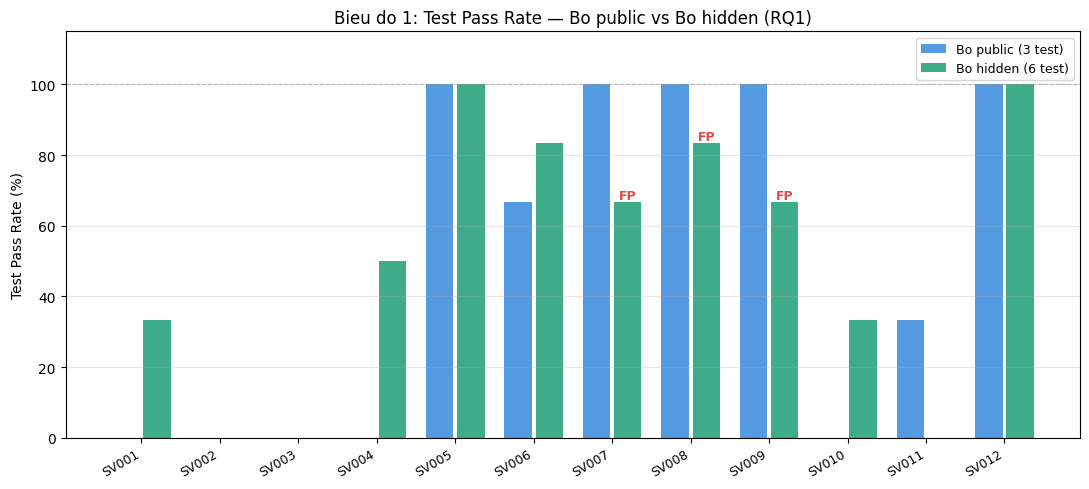

✓ Luu: results/bieu_do_1_tpr.png


In [11]:
import json, matplotlib.pyplot as plt, ast
from collections import Counter

with open("results/student_simulation.json", encoding="utf-8") as f:
    data = json.load(f)
rows = data["submissions"]

ids  = [r["sv_id"]   for r in rows]
pub  = [r["pub_tpr"] for r in rows]
hid  = [r["hid_tpr"] for r in rows]

fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(ids))
ax.bar([i-0.2 for i in x], pub, 0.35, label="Bo public (3 test)", color="#378ADD", alpha=.85)
ax.bar([i+0.2 for i in x], hid, 0.35, label="Bo hidden (6 test)", color="#1D9E75", alpha=.85)

for i, r in enumerate(rows):
    if r["is_false_positive"]:
        ax.annotate("FP", xy=(i+0.2, hid[i]+1), ha="center",
                    fontsize=9, color="#E24B4A", fontweight="bold")

ax.set_xticks(list(x))
ax.set_xticklabels(ids, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Test Pass Rate (%)")
ax.set_title("Bieu do 1: Test Pass Rate — Bo public vs Bo hidden (RQ1)")
ax.legend(fontsize=9)
ax.set_ylim(0, 115)
ax.axhline(100, ls="--", color="gray", lw=.8, alpha=.5)
ax.grid(axis="y", alpha=.3)
plt.tight_layout()
plt.savefig("results/bieu_do_1_tpr.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Luu: results/bieu_do_1_tpr.png")

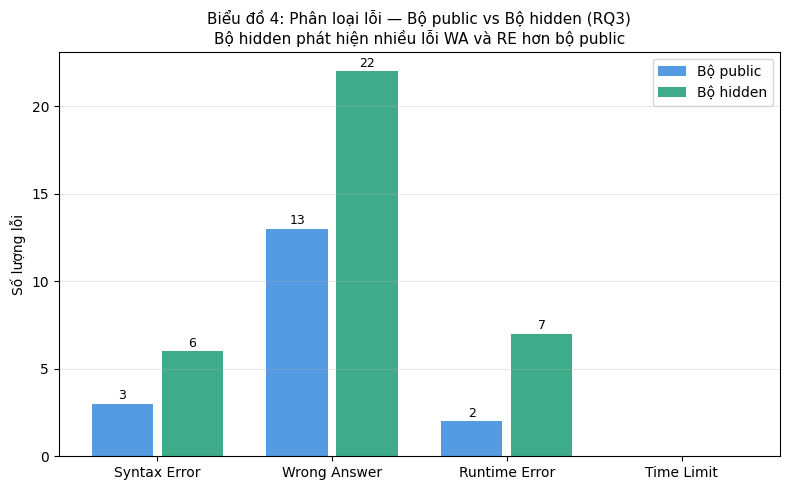

✓ Lưu: /content/drive/MyDrive/Project/results/bieu_do_2_loi.png


In [12]:
from collections import Counter

def count_errors(col):
    c = Counter()
    for r in rows:
        try:
            d = ast.literal_eval(r[col])
        except Exception:
            d = {}
        for k, v in d.items():
            c[k] += v
    return c

pub_err = count_errors("pub_errors")
hid_err = count_errors("hid_errors")

labels  = ["SE", "WA", "RE", "TLE"]
xlabels = ["Syntax Error", "Wrong Answer", "Runtime Error", "Time Limit"]
pub_v   = [pub_err.get(k, 0) for k in labels]
hid_v   = [hid_err.get(k, 0) for k in labels]

fig, ax = plt.subplots(figsize=(8, 5))
xb = range(len(labels))

b1 = ax.bar([i - 0.2 for i in xb], pub_v, 0.35,
            label="Bộ public", color="#378ADD", alpha=.85)
b2 = ax.bar([i + 0.2 for i in xb], hid_v, 0.35,
            label="Bộ hidden", color="#1D9E75", alpha=.85)

for bar in b1:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)
for bar in b2:
    if bar.get_height() > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

ax.set_xticks(list(xb))
ax.set_xticklabels(xlabels, fontsize=10)
ax.set_ylabel("Số lượng lỗi")
ax.set_title(
    "Biểu đồ 4: Phân loại lỗi — Bộ public vs Bộ hidden (RQ3)\n"
    "Bộ hidden phát hiện nhiều lỗi WA và RE hơn bộ public",
    fontsize=11
)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "bieu_do_2_loi.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"✓ Lưu: {OUT_DIR / 'bieu_do_2_loi.png'}")

✓ Data: mbpp_clean.json (15 bai)


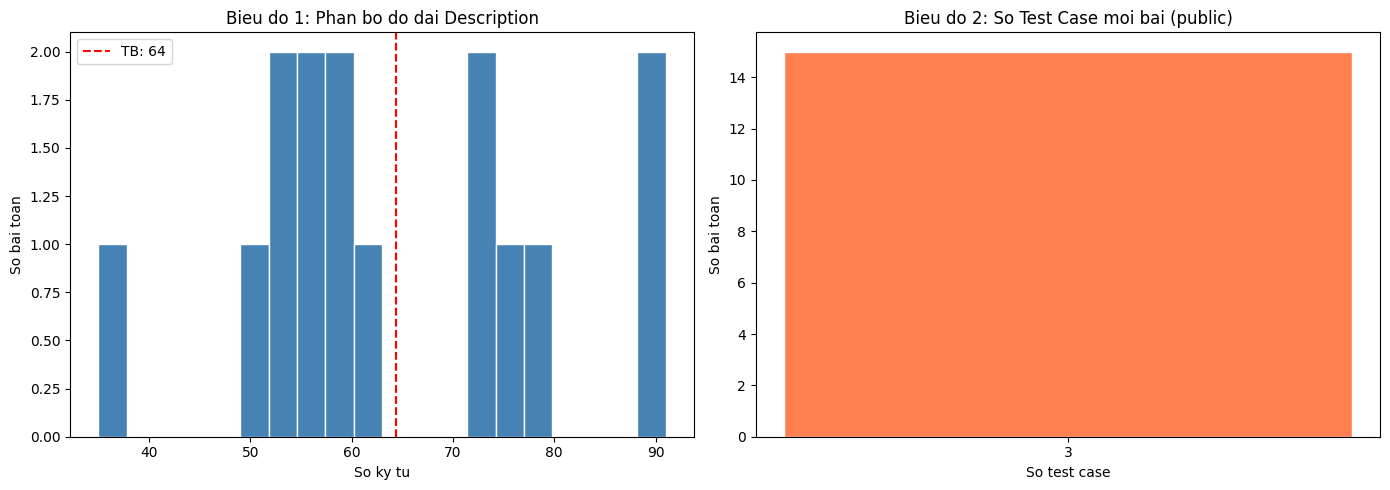

✅ Da luu bieu do vao results/


In [13]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.family"] = "DejaVu Sans"



data_path = BASE / "data" / "processed" / "mbpp_clean.json"

with open(data_path, encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df["desc_length"] = df["text"].fillna("").apply(len)

def _count_public_tests(row):
    pub = row.get("public_tests") or row.get("test_list") or []
    return len(pub)

df["num_tests"] = df.apply(_count_public_tests, axis=1)
print(f"✓ Data: {data_path.name} ({len(df)} bai)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["desc_length"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_title("Bieu do 1: Phan bo do dai Description")
axes[0].set_xlabel("So ky tu")
axes[0].set_ylabel("So bai toan")
axes[0].axvline(df["desc_length"].mean(), color="red", linestyle="--",
                label=f"TB: {df['desc_length'].mean():.0f}")
axes[0].legend()

test_counts = df["num_tests"].value_counts().sort_index()
axes[1].bar(test_counts.index.astype(str), test_counts.values, color="coral", edgecolor="white")
axes[1].set_title("Bieu do 2: So Test Case moi bai (public)")
axes[1].set_xlabel("So test case")
axes[1].set_ylabel("So bai toan")

plt.tight_layout()

(BASE / "results").mkdir(parents=True, exist_ok=True)

plt.savefig(BASE / "results" / "data_analysis.png", dpi=150)
plt.show()
print("✅ Da luu bieu do vao results/")

In [16]:
import shutil
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Project")
EXPORT_DIR = BASE / "results" / "exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Thêm data_analysis.png vào danh sách các file cần export
files_to_export = [
    "bieu_do_1_tpr.png",
    "bieu_do_2_loi.png",
    "data_analysis.png",
    "baseline_summary.csv",
    "student_simulation.csv",
    "metric_summary.json"
]

print(f"--- Bắt đầu export kết quả vào {EXPORT_DIR.name} ---")
for f in files_to_export:
    src = BASE / "results" / f
    dst = EXPORT_DIR / f
    if src.exists():
        shutil.copy(src, dst)
        print(f"  ✓ Đã chép: {f}")
    else:
        print(f"  ✗ Không tìm thấy: {f}")

print("\n✓ Tất cả tiến trình hoàn tất.")
print(f"Đường dẫn đích: {EXPORT_DIR}")

--- Bắt đầu export kết quả vào exports ---
  ✓ Đã chép: bieu_do_1_tpr.png
  ✓ Đã chép: bieu_do_2_loi.png
  ✓ Đã chép: data_analysis.png
  ✓ Đã chép: baseline_summary.csv
  ✓ Đã chép: student_simulation.csv
  ✓ Đã chép: metric_summary.json

✓ Tất cả tiến trình hoàn tất.
Đường dẫn đích: /content/drive/MyDrive/Project/results/exports
